In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV

import xgboost as xgb
from tqdm.auto import tqdm

import joblib
import os

In [47]:
ev2 =  pd.read_csv('../../Datasets/amazon_wjunwei_50.csv')
ev2.head(3)

,product_title,product_rating,log_total_reviews,log_purchased_last_month,is_sponsored,buy_box_availability,has_coupon,discount_percentage,product_category,brand_cat,...,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,5.883322,0.000000,Sponsored,1,0,0.0,PC Components,OTHER,...,0.014714,-0.008312,-0.008662,0.001077,-0.000999,0.011585,-0.005700,-0.005355,0.006623,0.027025
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,5.624018,0.000000,Sponsored,1,0,0.0,Storage & Memory Cards,OTHER,...,0.023068,0.019623,0.005455,0.009190,0.023171,0.007704,-0.015254,-0.005107,-0.009340,0.010308
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,11.523598,10.819798,Organic,0,0,0.0,"Office Supplies, Ink & Toner",HP,...,-0.001788,0.002831,-0.007012,0.007544,-0.000362,0.002696,0.003844,0.005124,-0.008396,-0.001894


In [48]:
target = 'log_original_price'

ev2.drop(columns=['product_title'], inplace=True)

## Modelo sin dividir en grupos

In [26]:
if 'original_price' not in ev2.columns:
    ev2['original_price'] = np.expm1(ev2['log_original_price'])

# ==============================================================================
# 2. SPLIT TRAIN/TEST
# ==============================================================================
X_temp = ev2.copy()
y_temp = ev2['log_original_price']

# Dividimos antes de nada para evitar Data Leakage en los umbrales
train_df, test_df = train_test_split(X_temp, test_size=0.20, random_state=42)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

# ==============================================================================
# 3. CÁLCULO DE UMBRALES (Solo con Train)
# ==============================================================================
def obtener_umbrales_iqr(df):
    umbrales = {}
    for cat in df['product_category'].unique():
        precios = df[df['product_category'] == cat]['original_price']
        
        if len(precios) > 5:
            q1 = precios.quantile(0.25)
            q3 = precios.quantile(0.75)
            iqr = q3 - q1
            umbrales[cat] = {
                'limite_baja': q1, 
                'limite_premium': q3 + (1.5 * iqr)
            }
        else:
            umbrales[cat] = {'limite_baja': 0, 'limite_premium': 999999}
    return umbrales

print("Calculando gamas de precios...")
dict_umbrales = obtener_umbrales_iqr(train_df)

# ==============================================================================
# 4. APLICACIÓN DE SEGMENTOS
# ==============================================================================
def asignar_segmento(row, umbrales_dict):
    cat = row['product_category']
    precio = row['original_price']
    
    if cat not in umbrales_dict: return 'Media'
    
    limites = umbrales_dict[cat]
    if precio <= limites['limite_baja']: return 'Baja'
    elif precio >= limites['limite_premium']: return 'Alta'
    else: return 'Media'

train_df['product_segment'] = train_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))
test_df['product_segment'] = test_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))

# ==============================================================================
# 5. LIMPIEZA FINAL (SIN OHE)
# ==============================================================================
print("Generando X_train y X_test sin One-Hot Encoding...")

# Columnas que definimos como categóricas
categorical_cols = [
    'is_sponsored', 'product_category', 'spec_resolution_cat', 
    'brand_cat', 'buy_box_availability', 'is_best_seller', 'product_segment'
]
# Validamos que existan
valid_cats = [c for c in categorical_cols if c in train_df.columns]

# Definimos qué borrar (Target, Textos crudos, Precios auxiliares)
cols_to_drop = [
    'log_original_price', 'original_price', 
    'product_title', 'clean_title', 'clean_title_bert'
]
# Borramos solo lo que exista
cols_to_drop = [c for c in cols_to_drop if c in train_df.columns]

# Creamos los datasets finales
X_train_final = train_df.drop(columns=cols_to_drop)
X_test_final = test_df.drop(columns=cols_to_drop)

# Paso Importante: Convertir objetos a 'category'
# Esto ayuda a modelos como LightGBM/CatBoost a reconocerlas automáticamente
for col in valid_cats:
    X_train_final[col] = X_train_final[col].astype('category')
    X_test_final[col]  = X_test_final[col].astype('category')

y_train = train_df['log_original_price']
y_test  = test_df['log_original_price']

print(f"✅ Proceso completado.")
print(f"Cols Train: {X_train_final.shape[1]}")
print(f"Ejemplo de columnas: {list(X_train_final.select_dtypes(include=['category']).columns)}")

Train size: 6173 | Test size: 1544
Calculando gamas de precios...
Generando X_train y X_test sin One-Hot Encoding...
✅ Proceso completado.
Cols Train: 70
Ejemplo de columnas: ['is_sponsored', 'buy_box_availability', 'product_category', 'brand_cat', 'spec_resolution_cat', 'is_best_seller', 'product_segment']


In [27]:
dtrain_reg = xgb.DMatrix(X_train_final, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test_final, y_test, enable_categorical=True)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': ['rmse', 'mae'],
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': 42
}

# ========================================
# PARTE 1: Entrenamiento inicial con barra
# ========================================
print("🚀 Entrenamiento inicial...")

# Callback para barra de progreso
class TqdmCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds):
        self.pbar = tqdm(total=total_rounds, desc="Training")
        self.best_score = float('inf')
    
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        
        # Actualizar métricas cada 50 iteraciones
        if epoch % 50 == 0 or epoch == 0:
            train_rmse = evals_log['train']['rmse'][-1]
            val_rmse = evals_log['val']['rmse'][-1]
            self.pbar.set_postfix({
                'train_rmse': f'{train_rmse:.4f}', 
                'val_rmse': f'{val_rmse:.4f}'
            })
        
        return False
    
    def after_training(self, model):
        self.pbar.close()
        return model

evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
model = xgb.train(
    params,
    dtrain_reg,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False,  # Desactivar verbose
    callbacks=[TqdmCallback(3000)]
)
best_iteration = model.best_iteration
print(f"✅ Mejor iteración: {best_iteration}\n")

# ========================================
# PARTE 2: RandomizedSearchCV con barra
# ========================================
print("🔍 Búsqueda de hiperparámetros...")

param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 5, 10, 50]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iteration,
    tree_method='hist',
    enable_categorical=True,
    verbosity=0  # Silenciar XGBoost
)

# Wrapper para mostrar progreso en RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV as OriginalRandomizedSearchCV
import sklearn.model_selection._validation as val_module

class TqdmRandomizedSearchCV(OriginalRandomizedSearchCV):
    def fit(self, X, y=None, **fit_params):
        # Total de fits = n_iter * cv_folds
        total = self.n_iter * (self.cv if isinstance(self.cv, int) else 5) 
        self.pbar = tqdm(total=total, desc="CV Progress")
        
        # Guardamos la función original del MÓDULO, no de self
        original_fit_and_score = val_module._fit_and_score
        
        def wrapped_fit_and_score(*args, **kwargs):
            result = original_fit_and_score(*args, **kwargs)
            self.pbar.update(1)
            return result
        
        # Reemplazamos temporalmente la función en el módulo
        val_module._fit_and_score = wrapped_fit_and_score
        
        try:
            # Ejecutar el fit original
            result = super().fit(X, y, **fit_params)
        finally:
            # Restauramos la función original siempre, incluso si hay error
            val_module._fit_and_score = original_fit_and_score
            self.pbar.close()
            
        return result

# El resto de tu configuración se mantiene igual
random_search = TqdmRandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)

print(f"\n✅ Búsqueda completada!")
print(f"📊 Mejores parámetros:")
for param, value in random_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n🎯 Mejor RMSE: {(-random_search.best_score_)**0.5:.4f}")


🚀 Entrenamiento inicial...


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

✅ Mejor iteración: 1507

🔍 Búsqueda de hiperparámetros...


CV Progress:   0%|          | 0/250 [00:00<?, ?it/s]


✅ Búsqueda completada!
📊 Mejores parámetros:
   • subsample: 0.6
   • reg_lambda: 1
   • reg_alpha: 0.1
   • min_child_weight: 3
   • max_depth: 7
   • learning_rate: 0.01
   • gamma: 0.1
   • colsample_bytree: 0.8

🎯 Mejor RMSE: 0.4501


In [28]:
folder_path = 'Modelos'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"📁 Carpeta '{folder_path}' creada.")

best_model = random_search.best_estimator_

model_2_path = os.path.join(folder_path, 'xgb_wjunwei_50.json')
best_model.save_model(model_2_path)

print(f"Mejores parámetros: {random_search.best_params_}")
print(f"💾 Mejor modelo guardado en: {model_2_path}")

Mejores parámetros: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
💾 Mejor modelo guardado en: Modelos\xgb_wjunwei_50.json


In [29]:
# Creamos un diccionario con los Dtypes y las Categorías exactas
metadata = {
    'dtypes': X_train_final.dtypes,
    'columns': X_train_final.columns.tolist(),
    'categories': {}
}

# Guardamos la lista de categorías para cada columna categórica
# Esto es vital para que "Dell" sea siempre "Dell" y no un número aleatorio
for col in X_train_final.select_dtypes(['category']).columns:
    metadata['categories'][col] = X_train_final[col].cat.categories

# Guardamos el archivo en tu carpeta de modelos
joblib.dump(metadata, 'Modelos/metadata_entrenamiento_wjunwei_50.pkl')
print("✅ Metadatos guardados: Ahora puedes predecir en cualquier notebook.")

✅ Metadatos guardados: Ahora puedes predecir en cualquier notebook.


RMSE: 0.414101049039238
MAE: 0.3275835892197172
R²: 0.8993342475699385


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

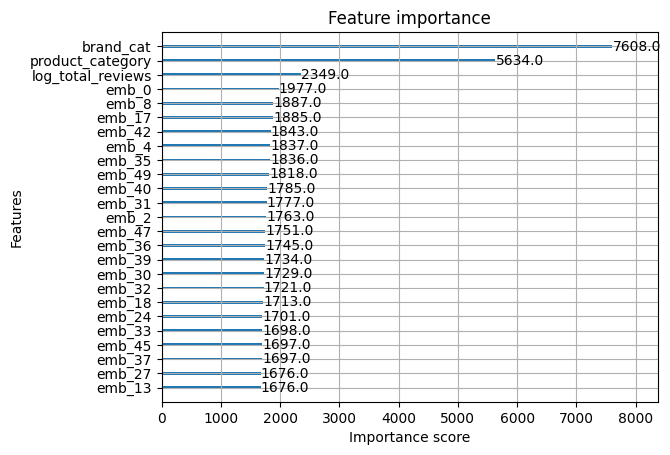

In [31]:
y_pred = best_model.predict(X_test_final)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R²: {r2_score(y_test, y_pred)}")

# Analizar importancia de features
xgb.plot_importance(best_model, max_num_features=25)

In [30]:
preds = best_model.predict(X_test_final)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(preds)

mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100


df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})


df_residuos['ErrorRelativo%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

for col in [c for c in X_test_final.columns if 'segment' in c]:
    mask = X_test_final[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'ErrorRelativo%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)


print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print(f"R2 Score (Calidad):      {r2_score(y_test_euro, y_pred_euro):.4f}")
# print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)


Segmento product_segment:
   - Error en Euros (MAE): nan €
   - Error en % (MAPE):    nan %
--------------------
📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      73.28 €
MedAE (Error Típico):   23.41 €
RMSE (Error Penalizado): 193.52 €
MAPE (Error Porcentual): 35.22 %
R2 Score (Calidad):      0.7986


## Modelo dividiendo en 3 grupos:
- DISPOSITIVOS: Tienen specs visuales/técnicas (Verde en Screen/RAM/Storage)


        - 'Laptops', 'TV & Video Displays', 'Mobile Cell Phones & Smartphones', 
        'Tablets & E-readers (DEVICES ONLY)', 'Video Game Consoles & Virtual Reality',
        'Cameras & Photography'


- COMPONENTES: Tienen specs técnicas internas (Verde en Storage/Power)


        - 'PC Components', 'Storage & Memory Cards', 'Power & Batteries', 
        'Chargers, Adapters & Cables', 'Networking'


- ACCESORIOS: Todo Rojo en specs. Se basan en Texto, Marca y Pack


        - 'Office Supplies, Ink & Toner', 'Computer Peripherals', 
        'Audio, Sound & Recording Gear', 'Small Gadget Accessories (Cases & Protectors)',
        'Wearables', 'Smart Home & Security', 'Printers & Scanners (Hardware)',
        'Other Electronics'

In [49]:
# ==============================================================================
# 1. DEFINICIÓN DE GRUPOS DE EXPERTOS (Basado en tu Heatmap)
# ==============================================================================
# Agrupamos las categorías según qué datos tienen disponibles (Colores del Heatmap)
GRUPOS_EXPERTOS = {
    'DISPOSITIVOS': [ # Tienen specs visuales/técnicas (Verde en Screen/RAM/Storage)
        'Laptops', 'TV & Video Displays', 'Mobile Cell Phones & Smartphones', 
        'Tablets & E-readers (DEVICES ONLY)', 'Video Game Consoles & Virtual Reality',
        'Cameras & Photography' # Por precio va aquí, aunque tenga pocas specs detectadas
    ],
    'COMPONENTES': [ # Tienen specs técnicas internas (Verde en Storage/Power)
        'PC Components', 'Storage & Memory Cards', 'Power & Batteries', 
        'Chargers, Adapters & Cables', 'Networking'
    ],
    'ACCESORIOS': [ # Todo Rojo en specs. Se basan en Texto, Marca y Pack
        'Office Supplies, Ink & Toner', 'Computer Peripherals', 
        'Audio, Sound & Recording Gear', 'Small Gadget Accessories (Cases & Protectors)',
        'Wearables', 'Smart Home & Security', 'Printers & Scanners (Hardware)',
        'Other Electronics'
    ]
}

# Definimos qué columnas de Specs BORRAR para cada grupo porque son puro ruido (0% datos)
COLS_RUIDO_POR_GRUPO = {
    'DISPOSITIVOS': [], # Usamos todas las specs
    'COMPONENTES': ['spec_screen_inch', 'spec_resolution_cat'], # No tienen pantalla
    'ACCESORIOS': ['spec_screen_inch', 'spec_resolution_cat', 'spec_ram_gb', 
                   'spec_storage_gb', 'spec_ram_speed_mhz', 'spec_refresh_rate_hz'] # Todo a la basura
}

# ==============================================================================
# 2. PREPARACIÓN INICIAL
# ==============================================================================
if 'original_price' not in ev2.columns:
    ev2['original_price'] = np.expm1(ev2['log_original_price'])

X_temp = ev2.copy()

# Dividimos GLOBALMENTE primero (80/20) para mantener la distribución
train_df_global, test_df_global = train_test_split(X_temp, test_size=0.20, random_state=42)

print(f"Global Train size: {len(train_df_global)} | Global Test size: {len(test_df_global)}")

# ==============================================================================
# 3. CÁLCULO DE UMBRALES
# ==============================================================================
def obtener_umbrales_iqr(df):
    umbrales = {}
    for cat in df['product_category'].unique():
        precios = df[df['product_category'] == cat]['original_price']
        if len(precios) > 5:
            q1 = precios.quantile(0.25)
            q3 = precios.quantile(0.75)
            iqr = q3 - q1
            umbrales[cat] = {
                'limite_baja': q1, 
                'limite_premium': q3 + (1.5 * iqr)
            }
        else:
            umbrales[cat] = {'limite_baja': 0, 'limite_premium': 999999}
    return umbrales

print("Calculando gamas de precios (Low/Mid/High)...")
dict_umbrales = obtener_umbrales_iqr(train_df_global)

# ==============================================================================
# 4. APLICACIÓN DE SEGMENTOS
# ==============================================================================
def asignar_segmento(row, umbrales_dict):
    cat = row['product_category']
    precio = row['original_price']
    if cat not in umbrales_dict: return 'Media'
    limites = umbrales_dict[cat]
    if precio <= limites['limite_baja']: return 'Baja'
    elif precio >= limites['limite_premium']: return 'Alta'
    else: return 'Media'

# Aplicamos segmento a todo el dataset global
train_df_global['product_segment'] = train_df_global.apply(asignar_segmento, axis=1, args=(dict_umbrales,))
test_df_global['product_segment'] = test_df_global.apply(asignar_segmento, axis=1, args=(dict_umbrales,))

# ==============================================================================
# 5. DIVISIÓN Y LIMPIEZA POR GRUPO
# ==============================================================================
datasets_por_grupo = {}

print("\n🔪 Dividiendo en 3 Expertos y limpiando columnas...")

for nombre_grupo, categorias_grupo in GRUPOS_EXPERTOS.items():
    
    # A. Filtrar filas para este grupo
    train_subset = train_df_global[train_df_global['product_category'].isin(categorias_grupo)].copy()
    test_subset  = test_df_global[test_df_global['product_category'].isin(categorias_grupo)].copy()
    
    if len(train_subset) == 0:
        print(f"⚠️ Grupo {nombre_grupo} vacío. Saltando.")
        continue

    # B. Definir columnas a borrar
    # 1. Las estándar (Target, Textos, etc.)
    drop_standard = [
        'log_original_price', 'original_price', 
        'product_title', 'clean_title', 'clean_title_bert'
    ]
    # 2. Las específicas del grupo (Specs vacías según Heatmap)
    drop_specs = COLS_RUIDO_POR_GRUPO.get(nombre_grupo, [])
    
    cols_to_drop = list(set(drop_standard + drop_specs))
    
    # Validar que existan antes de borrar
    cols_to_drop_train = [c for c in cols_to_drop if c in train_subset.columns]
    
    # C. Crear X e y
    X_train = train_subset.drop(columns=cols_to_drop_train)
    y_train = train_subset['log_original_price']
    
    X_test = test_subset.drop(columns=cols_to_drop_train) # Mismas columnas borradas
    y_test = test_subset['log_original_price']
    
    # D. Casting de Categorías
    categorical_cols = [
        'is_sponsored', 'product_category', 'spec_resolution_cat', 
        'brand_cat', 'buy_box_availability', 'is_best_seller', 'product_segment'
    ]
    # Filtramos las columnas categóricas que REALMENTE quedan en este grupo
    cats_activas = [c for c in categorical_cols if c in X_train.columns]
    
    for col in cats_activas:
        X_train[col] = X_train[col].astype('category')
        X_test[col]  = X_test[col].astype('category')
        
    # E. Guardar en el diccionario maestro
    datasets_por_grupo[nombre_grupo] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }
    
    print(f"✅ {nombre_grupo}: Train {X_train.shape} | Test {X_test.shape}")
    print(f"   -> Specs eliminadas: {drop_specs}")

print("\nDiccionario 'datasets_por_grupo' listo para entrenar.")

Global Train size: 6173 | Global Test size: 1544
Calculando gamas de precios (Low/Mid/High)...

🔪 Dividiendo en 3 Expertos y limpiando columnas...
✅ DISPOSITIVOS: Train (1417, 70) | Test (333, 70)
   -> Specs eliminadas: []
✅ COMPONENTES: Train (1501, 68) | Test (394, 68)
   -> Specs eliminadas: ['spec_screen_inch', 'spec_resolution_cat']
✅ ACCESORIOS: Train (3255, 64) | Test (817, 64)
   -> Specs eliminadas: ['spec_screen_inch', 'spec_resolution_cat', 'spec_ram_gb', 'spec_storage_gb', 'spec_ram_speed_mhz', 'spec_refresh_rate_hz']

Diccionario 'datasets_por_grupo' listo para entrenar.


In [50]:
# Configuración de rutas
PATH_MODELOS = 'Modelos_Especialistas'
if not os.path.exists(PATH_MODELOS):
    os.makedirs(PATH_MODELOS)

# Diccionario para guardar resultados finales
resultados_finales = {}

print("🚀 INICIANDO ENTRENAMIENTO MULTI-EXPERTO\n")

for nombre_grupo, data in datasets_por_grupo.items():
    print(f"\n{'='*60}")
    print(f"🏭 ENTRENANDO EXPERTO: {nombre_grupo}")
    print(f"{'='*60}")
    
    X_train = data['X_train']
    y_train = data['y_train']
    X_test = data['X_test']
    y_test = data['y_test']
    
    # ========================================
    # PARTE 1: Entrenamiento inicial (Para hallar best_iteration)
    # ========================================
    print(f"   🏃 Fase 1: Calentamiento y búsqueda de n_estimators...")
    
    dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
    dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

    params_initial = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse', # Simplificado a uno solo para evitar errores de log
        'tree_method': 'hist',
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
    
    model_init = xgb.train(
        params_initial,
        dtrain_reg,
        num_boost_round=3000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False,
        callbacks=[TqdmCallback(3000)]
    )
    
    best_iter = model_init.best_iteration
    print(f"   ✅ Mejor iteración detectada: {best_iter}")
    
    # ========================================
    # PARTE 2: RandomizedSearchCV (Tuning Fino)
    # ========================================
    print(f"   🔍 Fase 2: Tuning de Hiperparámetros ({nombre_grupo})...")
    
    param_dist = {
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.03, 0.05], # Ajustado un poco para afinar
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.6, 0.8],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.5],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 5, 10]
    }

    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=best_iter, # Usamos el valor óptimo detectado antes
        tree_method='hist',
        enable_categorical=True,
        n_jobs=-1,
        verbosity=0
    )
    
    random_search = TqdmRandomizedSearchCV(
        xgb_model,
        param_distributions=param_dist,
        n_iter=20, # Reducido a 20 por grupo para que no tarde horas (ajústalo si quieres)
        scoring='neg_mean_squared_error',
        cv=3,      # CV de 3 pliegues es suficiente para validación rápida
        verbose=0,
        random_state=42,
        n_jobs=-1
    )
    
    # Entrenar búsqueda
    random_search.fit(X_train, y_train)
    
    best_model = random_search.best_estimator_
    best_rmse = (-random_search.best_score_)**0.5
    
    print(f"   🎯 Mejor RMSE CV: {best_rmse:.4f}")
    
    # ========================================
    # PARTE 3: Guardado de Modelo y Metadatos
    # ========================================
    print(f"   💾 Fase 3: Guardando experto...")
    
    # 1. Guardar Modelo JSON
    path_json = os.path.join(PATH_MODELOS, f'xgb_wjunwei_{nombre_grupo}.json')
    best_model.save_model(path_json)
    
    # 2. Guardar Metadatos (Vital para tu Router)
    # Extraemos el mapa de categorías real usado en el entrenamiento
    cat_cols = X_train.select_dtypes(include=['category']).columns
    cat_map = {c: X_train[c].cat.categories for c in cat_cols}
    
    metadata = {
        'columns': X_train.columns.tolist(),
        'dtypes': X_train.dtypes.to_dict(),
        'categories': cat_map,
        'best_params': random_search.best_params_,
        'best_rmse': best_rmse
    }
    path_meta = os.path.join(PATH_MODELOS, f'meta_wjunwei_{nombre_grupo}.pkl')
    joblib.dump(metadata, path_meta)
    
    resultados_finales[nombre_grupo] = best_rmse
    print(f"   ✅ Experto {nombre_grupo} guardado exitosamente.")

print("\n" + "="*60)
print("🏆 PROCESO FINALIZADO. RESUMEN DE RMSE POR GRUPO:")
for k, v in resultados_finales.items():
    print(f"   • {k}: {v:.4f}")
print("="*60)

🚀 INICIANDO ENTRENAMIENTO MULTI-EXPERTO


🏭 ENTRENANDO EXPERTO: DISPOSITIVOS
   🏃 Fase 1: Calentamiento y búsqueda de n_estimators...


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

   ✅ Mejor iteración detectada: 279
   🔍 Fase 2: Tuning de Hiperparámetros (DISPOSITIVOS)...


CV Progress:   0%|          | 0/60 [00:00<?, ?it/s]

   🎯 Mejor RMSE CV: 0.5092
   💾 Fase 3: Guardando experto...
   ✅ Experto DISPOSITIVOS guardado exitosamente.

🏭 ENTRENANDO EXPERTO: COMPONENTES
   🏃 Fase 1: Calentamiento y búsqueda de n_estimators...


...

   🎯 Mejor RMSE CV: 0.4523
   💾 Fase 3: Guardando experto...
   ✅ Experto COMPONENTES guardado exitosamente.

🏭 ENTRENANDO EXPERTO: ACCESORIOS
   🏃 Fase 1: Calentamiento y búsqueda de n_estimators...


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

   ✅ Mejor iteración detectada: 635
   🔍 Fase 2: Tuning de Hiperparámetros (ACCESORIOS)...


CV Progress:   0%|          | 0/60 [00:00<?, ?it/s]

   🎯 Mejor RMSE CV: 0.4657
   💾 Fase 3: Guardando experto...
   ✅ Experto ACCESORIOS guardado exitosamente.

🏆 PROCESO FINALIZADO. RESUMEN DE RMSE POR GRUPO:
   • DISPOSITIVOS: 0.5092
   • COMPONENTES: 0.4523
   • ACCESORIOS: 0.4657


In [51]:
# Contenedor para acumular resultados de TODOS los grupos
df_global_residuos = pd.DataFrame()

print("📊 EVALUACIÓN DETALLADA POR EXPERTO\n")

for nombre_grupo, data in datasets_por_grupo.items():
    print(f"🔹 GRUPO: {nombre_grupo}")
    
    # 1. Cargar datos y Modelo
    X_test = data['X_test']
    y_test = data['y_test']
    
    # Cargar el modelo específico de este grupo
    path_modelo = os.path.join(PATH_MODELOS, f'xgb_wjunwei_{nombre_grupo}.json')
    model = xgb.XGBRegressor()
    model.load_model(path_modelo)
    
    # 2. Predecir
    # (XGBoost maneja las categorías automáticamente porque lo guardamos así)
    dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)
    preds_log = model.predict(X_test) # Nota: predict en sklearn API usa X_test directo
    
    # 3. Invertir Logaritmo
    y_real_euro = np.expm1(y_test)
    y_pred_euro = np.expm1(preds_log)
    
    # 4. Calcular Métricas del Grupo
    mae = mean_absolute_error(y_real_euro, y_pred_euro)
    rmse = np.sqrt(mean_squared_error(y_real_euro, y_pred_euro))
    mape = np.mean(np.abs((y_real_euro - y_pred_euro) / y_real_euro)) * 100
    r2 = r2_score(y_real_euro, y_pred_euro)
    
    print(f"   • MAE:  {mae:.2f} €")
    print(f"   • RMSE: {rmse:.2f} €")
    print(f"   • MAPE: {mape:.2f} %")
    print(f"   • R2:   {r2:.4f}")
    
    # 5. Guardar en DataFrame de Residuos Local
    df_local = pd.DataFrame({
        'Grupo': nombre_grupo,
        'Real': y_real_euro,
        'Pred': y_pred_euro,
        'Error_Abs': np.abs(y_real_euro - y_pred_euro),
        # Recuperamos el segmento si existe en X_test para el desglose final
        'Segmento': X_test['product_segment'] if 'product_segment' in X_test.columns else 'Unknown'
    })
    
    # Acumular en el global
    df_global_residuos = pd.concat([df_global_residuos, df_local], axis=0)
    print("-" * 30)

# ==============================================================================
# EVALUACIÓN GLOBAL (EL "BIG PICTURE")
# ==============================================================================
print("\n" + "="*40)
print("🌍 MÉTRICAS GLOBALES DEL SISTEMA (LOS 3 MODELOS JUNTOS)")
print("="*40)

# Calculamos métricas sobre todo el conjunto acumulado
y_real_total = df_global_residuos['Real']
y_pred_total = df_global_residuos['Pred']

mae_global = mean_absolute_error(y_real_total, y_pred_total)
rmse_global = np.sqrt(mean_squared_error(y_real_total, y_pred_total))
medae_global = median_absolute_error(y_real_total, y_pred_total)
mape_global = np.mean(np.abs((y_real_total - y_pred_total) / y_real_total)) * 100
r2_global = r2_score(y_real_total, y_pred_total)

print(f"MAE Total:      {mae_global:.2f} €")
print(f"RMSE Total:     {rmse_global:.2f} €")
print(f"MedAE (Típico): {medae_global:.2f} €")
print(f"MAPE Total:     {mape_global:.2f} %")
print(f"R2 Score Total: {r2_global:.4f}")

# ==============================================================================
# DESGLOSE POR SEGMENTO (Baja / Media / Alta)
# ==============================================================================
print("\n📊 DESGLOSE DE ERROR POR SEGMENTO DE PRECIO (GLOBAL)")
df_global_residuos['ErrorRelativo%'] = (df_global_residuos['Error_Abs'] / df_global_residuos['Real']) * 100

# Agrupamos por la columna 'Segmento' que recuperamos antes
segmentos_stats = df_global_residuos.groupby('Segmento')[['Error_Abs', 'ErrorRelativo%']].mean()

for segmento in segmentos_stats.index:
    mae_seg = segmentos_stats.loc[segmento, 'Error_Abs']
    mape_seg = segmentos_stats.loc[segmento, 'ErrorRelativo%']
    
    print(f"Segmento {segmento}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {mape_seg:.2f} %")
    print("-" * 20)

📊 EVALUACIÓN DETALLADA POR EXPERTO

🔹 GRUPO: DISPOSITIVOS
   • MAE:  150.07 €
   • RMSE: 347.24 €
   • MAPE: 34.93 %
   • R2:   0.7610
------------------------------
🔹 GRUPO: COMPONENTES
   • MAE:  56.50 €
   • RMSE: 146.90 €
   • MAPE: 36.32 %
   • R2:   0.8342
------------------------------
🔹 GRUPO: ACCESORIOS
   • MAE:  54.07 €
   • RMSE: 121.60 €
   • MAPE: 36.88 %
   • R2:   0.7070
------------------------------

🌍 MÉTRICAS GLOBALES DEL SISTEMA (LOS 3 MODELOS JUNTOS)
MAE Total:      75.39 €
RMSE Total:     198.33 €
MedAE (Típico): 23.14 €
MAPE Total:     36.32 %
R2 Score Total: 0.7885

📊 DESGLOSE DE ERROR POR SEGMENTO DE PRECIO (GLOBAL)
Segmento Alta:
   - Error en Euros (MAE): 306.22 €
   - Error en % (MAPE):    29.60 %
--------------------
Segmento Baja:
   - Error en Euros (MAE): 9.11 €
   - Error en % (MAPE):    37.86 %
--------------------
Segmento Media:
   - Error en Euros (MAE): 68.43 €
   - Error en % (MAPE):    36.67 %
--------------------


C:\Users\diego\AppData\Local\Temp\ipykernel_19972\3406223344.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmentos_stats = df_global_residuos.groupby('Segmento')[['Error_Abs', 'ErrorRelativo%']].mean()
